In [273]:
import numpy as np
import pandas as pd

In [274]:
# columns = ['Date','Season','HomeTeam','AwayTeam','FTHG','FTAG','FTR','Referee','HS','AS','HST','AST', 'HF','AF','HC','AC','HY','AY','HR','AR',
#             'B365H','B365D','B365A']
# df = pd.read_csv('/home/milan/ml_projects/pl_ml/artifacts/train.csv',usecols=columns)
# df['Season']  = df['Season'].astype(str)
# # df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [310]:
TRAIN_PATH = '/home/milan/ml_projects/pl_ml/artifacts/train.csv'
TEST_PATH = '/home/milan/ml_projects/pl_ml/artifacts/test.csv'

In [ ]:
class FeatureEngineering():
    def __init__(self,path,window=5):
        self.columns = ['Date','Season','HomeTeam','AwayTeam','FTHG','FTAG','FTR','Referee','HS','AS','HST','AST', 'HF','AF','HC','AC','HY','AY','HR','AR',
            'B365H','B365D','B365A']
        self.df = pd.read_csv(path,usecols=self.columns)
        self.window = window
    
    def get_elo(self):

        self.df = self.df.sort_values(by=['Date']).reset_index(drop=True)
        all_teams = set(self.df['HomeTeam']).union(set(self.df['AwayTeam']))
        elo_ratings = {team: 1500 for team in all_teams}

            # Arrays to store ELO before the match happens
        home_elo_before = []
        away_elo_before = []

        K = 20 # ELO volatility factor
        HOME_ADV = 100

        for idx, row in self.df.iterrows():
            home, away, r = row['HomeTeam'], row['AwayTeam'], row['FTR']
                
            # Store current ELOs before the match
            h_elo = elo_ratings[home]
            a_elo = elo_ratings[away]
            home_elo_before.append(h_elo)
            away_elo_before.append(a_elo)
                
            # Expected outcomes
            E_H = 1 / (1 + 10 ** ((a_elo - (h_elo + HOME_ADV)) / 400))
            E_A = 1-E_H
                
            # Actual outcomes
            S_H = 1 if r == 'H' else (0.5 if r == 'D' else 0)
            S_A = 1 if r == 'A' else (0.5 if r == 'D' else 0)
                
            # Update ratings
            elo_ratings[home] = h_elo + K * (S_H - E_H)
            elo_ratings[away] = a_elo + K * (S_A - E_A)

        #     # Assign ELO columns
        # home_elo_before.pop()
        # away_elo_before.pop()
        self.df['Home_ELO'] = home_elo_before
        self.df['Away_ELO'] = away_elo_before

    def get_difference(self):
        self.df['ELO_Difference'] = self.df['Home_ELO']-self.df['Away_ELO']
        self.df['GoalDifference'] = self.df['HomeRollingGoalsScored'] - self.df['AwayRollingGoalsScored']
        self.df['ConceededDifference'] = self.df['HomeRollingGoalsConceeded'] - self.df['AwayRollingGoalsConceeded']

    def get_individual_teams(self):
        self.df['HomePoints'] = self.df['FTR'].map({'H':3,'D':1,'A':0})
        self.df['AwayPoints'] = self.df['FTR'].map({'H':0,'D':1,'A':3})


        home_df = self.df[['Date','Season','HomeTeam', 'FTHG','FTAG', 'HS', 'HomePoints','HST','HF','HC']].copy()
        home_df.columns = ['Date','Season', 'Team', 'GoalsScored','GoalsConceeded' ,'Shots', 'Points','STarget','Freekick','Corner'] 
        home_df['IsHome'] = True


        away_df = self.df[['Date','Season', 'AwayTeam', 'FTAG','FTHG','AS', 'AwayPoints','AST','AF','AC']].copy()
        away_df.columns = ['Date', 'Season','Team', 'GoalsScored','GoalsConceeded', 'Shots', 'Points','STarget','Freekick','Corner'] 
        away_df['IsHome'] = False

        melted = pd.concat([home_df, away_df], ignore_index=True)


        melted = melted.sort_values(by=['Date']).reset_index(drop=True)

        return melted
    
    def get_rolling_features(self,fill_values=None,window=5):
        melted = self.get_individual_teams()
        melted['RollingGoalsScored'] = melted.groupby('Team')['GoalsScored'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingGoalsConceeded'] = melted.groupby('Team')['GoalsConceeded'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingShots'] = melted.groupby('Team')['Shots'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingPoints'] = melted.groupby('Team')['Points'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingSTarget'] = melted.groupby('Team')['STarget'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingFreekick'] = melted.groupby('Team')['Freekick'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['RollingCorner'] = melted.groupby('Team')['Corner'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
        melted['TotalPoints'] = melted.groupby(['Season','Team'])['Points'].transform(lambda x:x.cumsum().shift(1))
        # melted['TotalGoalsScored'] = melted.groupby(['Season','Team'])['GoalsScored'].transform(lambda x:x.cumsum().shift(1))
        # melted['TotalGoalsConceeded'] = melted.groupby(['Season','Team'])['GoalsConceeded'].transform(lambda x:x.cumsum().shift(1))


        return melted

    def get_win_probabilities(self):
        self.df['H_P'] = 1/self.df['B365H']
        self.df['D_P'] = 1/self.df['B365D']
        self.df['A_P'] = 1/self.df['B365A']
        self.df['Max_Prob'] = self.df[['H_P', 'D_P', 'A_P']].max(axis=1)
        # self.df['Prob_Diff'] = self.df['H_P'] - self.df['A_P']
    
    # def drop_columns(self ,drop_cols):
    #     self.df.drop(columns = drop_cols , inplace = True)
    # def only_home_away_stats(self):
    #     melted = self.get_individual_teams()
    #     # melted['Goals_scored_home'] = melted[melted['IsHome']]['GoalsScored']
    #     # melted['Goals_scored_away'] = melted[~melted['IsHome']]['GoalsScored']
    #     # melted['Goals_conceeded_home'] = melted[melted['IsHome']]['GoalsConceeded']
    #     # melted['Goals_conceeded_away'] = melted[~melted['IsHome']]['GoalsConceeded']
    #     return melted

    

    def get_final_df(self,fill_values=None):
        # Calculate ELO and ELO differences first
        self.get_elo()


        # Compute rolling features
        melted = self.get_rolling_features()
        home_stats = melted[melted['IsHome']].drop(columns=['GoalsScored','GoalsConceeded','Season', 'Shots', 'Points','IsHome','STarget','Freekick','Corner'])
        away_stats = melted[~melted['IsHome']].drop(columns=['GoalsScored','GoalsConceeded','Season', 'Shots', 'Points','IsHome','STarget','Freekick','Corner'])

        home_stats.columns = ['Date', 'HomeTeam','HomeRollingGoalsScored','HomeRollingGoalsConceeded','HomeRollingShots', 'HomeRollingPoints','HomeRollingSTarget','HomeRollingFreekick','HomeRollingCorner','HomeTotalPoints']
        away_stats.columns = ['Date', 'AwayTeam','AwayRollingGoalsScored','AwayRollingGoalsConceeded','AwayRollingShots', 'AwayRollingPoints','AwayRollingSTarget','AwayRollingFreekick','AwayRollingCorner','AwayTotalPoints']

        self.df = self.df.merge(home_stats,how = 'left' , on = ['Date','HomeTeam'])
        self.df = self.df.merge(away_stats,how = 'left' , on = ['Date','AwayTeam'])
        
        # Define default fill values for rolling stats
        if fill_values:
            fill_values = {
                'HomeRollingPoints': 1.52, 'AwayRollingPoints': 1.24,
                'HomeRollingGoalsScored': 1.53, 'AwayRollingGoalsScored': 1.35,
                'HomeRollingGoalsConceeded': 1.35, 'AwayRollingGoalsConceeded': 1.53, 
                'HomeRollingShots': 12.59, 'AwayRollingShots': 12.70,
                'HomeRollingSTarget': 4.37, 'AwayRollingSTarget': 4.47,
                'HomeRollingFreekick': 11.08, 'AwayRollingFreekick': 11.0,
                'HomeRollingCorner': 5.08, 'AwayRollingCorner': 5.13,
                'HomeTotalPoints': 0, 'AwayTotalPoints': 0
            }
        
            self.df = self.df.fillna(value=fill_values)

        # Compute probabilities from betting odds
        self.get_win_probabilities()
        self.get_difference()
        # Map Target variable
        label2idx = {'H': 0, 'D': 1, 'A': 2}
        self.df['Target'] = self.df['FTR'].map(label2idx)

        # Select only the features and target we need
        features_and_target = [
            'Home_ELO', 'Away_ELO', 'ELO_Difference','GoalDifference','ConceededDifference',
            'HomeRollingGoalsScored', 'HomeRollingGoalsConceeded', 'HomeRollingShots',
            'HomeRollingPoints', 'HomeRollingSTarget', 'HomeRollingFreekick', 'HomeRollingCorner', 'HomeTotalPoints',
            'AwayRollingGoalsScored', 'AwayRollingGoalsConceeded', 'AwayRollingShots',
            'AwayRollingPoints', 'AwayRollingSTarget', 'AwayRollingFreekick', 'AwayRollingCorner', 'AwayTotalPoints',
            'H_P', 'D_P', 'A_P', 'Max_Prob', 'Target'
        ]
        self.df = self.df[features_and_target]

        # Drop any row that still has NaNs in the selected columns (e.g. if betting odds were missing)
        self.df.dropna(inplace=True)

        return self.df


                
                    


In [347]:
train_fe = FeatureEngineering(TRAIN_PATH)
final_df = train_fe.get_final_df()
test_fe = FeatureEngineering(TEST_PATH)
final_test_df = test_fe.get_final_df()

In [348]:
final_df.head(10)

,Home_ELO,Away_ELO,ELO_Difference,GoalDifference,ConceededDifference,HomeRollingGoalsScored,HomeRollingGoalsConceeded,HomeRollingShots,HomeRollingPoints,HomeRollingSTarget,...,AwayRollingPoints,AwayRollingSTarget,AwayRollingFreekick,AwayRollingCorner,AwayTotalPoints,H_P,D_P,A_P,Max_Prob,Target
10,1500,1500,0,1.0,3.0,1.0,4.0,12.0,0.0,5.0,...,0.0,2.0,12.0,5.0,0.0,0.444444,0.303030,0.303030,0.444444,0
11,1492.8013,1487.1987,5.6026,3.0,-5.0,3.0,0.0,5.0,3.0,3.0,...,0.0,3.0,6.0,1.0,0.0,0.392157,0.307692,0.348432,0.392157,1
12,1512.8013,1487.1987,25.6026,0.0,-3.0,0.0,0.0,10.0,1.0,3.0,...,0.0,3.0,15.0,5.0,0.0,0.581395,0.263158,0.210526,0.581395,0
13,1502.8013,1487.1987,15.6026,0.0,2.0,1.0,3.0,7.0,0.0,4.0,...,1.0,3.0,10.0,3.0,1.0,0.434783,0.294118,0.322581,0.434783,2
14,1492.8013,1497.1987,-4.3974,-4.0,2.0,0.0,3.0,11.0,0.0,3.0,...,3.0,7.0,9.0,11.0,3.0,0.153846,0.210526,0.694444,0.694444,2
15,1492.8013,1507.1987,-14.3974,2.0,-1.0,5.0,0.0,14.0,3.0,9.0,...,3.0,7.0,13.0,14.0,3.0,0.735294,0.190476,0.125000,0.735294,1
16,1512.8013,1507.1987,5.6026,-2.0,0.0,1.0,0.0,8.0,3.0,2.0,...,3.0,4.0,6.0,2.0,3.0,0.769231,0.181818,0.100000,0.769231,0
17,1512.8013,1507.1987,5.6026,0.0,4.0,0.0,4.0,18.0,0.0,7.0,...,1.0,1.0,3.0,12.0,1.0,0.588235,0.266667,0.200000,0.588235,1
18,1492.8013,1497.1987,-4.3974,1.0,1.0,1.0,1.0,8.0,1.0,3.0,...,1.0,2.0,16.0,6.0,1.0,0.392157,0.322581,0.344828,0.392157,0
19,1502.8013,1497.1987,5.6026,-4.0,0.0,0.0,0.0,8.0,1.0,2.0,...,3.0,5.0,15.0,3.0,3.0,0.303030,0.303030,0.444444,0.444444,1


In [314]:
final_df.columns

Index(['Home_ELO', 'Away_ELO', 'ELO_Difference', 'GoalDifference',
       'ConceededDifference', 'HomeRollingGoalsScored',
       'HomeRollingGoalsConceeded', 'HomeRollingShots', 'HomeRollingPoints',
       'HomeRollingSTarget', 'HomeRollingFreekick', 'HomeRollingCorner',
       'HomeTotalPoints', 'AwayRollingGoalsScored',
       'AwayRollingGoalsConceeded', 'AwayRollingShots', 'AwayRollingPoints',
       'AwayRollingSTarget', 'AwayRollingFreekick', 'AwayRollingCorner',
       'AwayTotalPoints', 'H_P', 'D_P', 'A_P', 'Max_Prob', 'Target'],
      dtype='str')

In [315]:
final_test_df['Target'].value_counts(normalize=True)

Target
0    0.416216
2    0.324324
1    0.259459
Name: proportion, dtype: float64

In [316]:

# # df['Date'] = pd.to_datetime(df['Date'])
# # df = df.sort_values('Date').reset_index(drop=True)

# # Initialize ELO dictionary (Starting rating of 1500 for all teams)
# all_teams = set(df['HomeTeam']).union(set(df['AwayTeam']))
# elo_ratings = {team: 1500 for team in all_teams}

# # Arrays to store ELO before the match happens
# home_elo_before = []
# away_elo_before = []

# K = 100 # ELO volatility factor

# for idx, row in df.iterrows():
#     home, away, r = row['HomeTeam'], row['AwayTeam'], row['FTR']
    
#     # Store current ELOs before the match
#     h_elo = elo_ratings[home]
#     a_elo = elo_ratings[away]
#     home_elo_before.append(h_elo)a
#     away_elo_before.append(a_elo)
    
#     # Expected outcomes
#     E_H = 1 / (1 + 10 ** ((a_elo - h_elo) / 400))
#     E_A = 1 / (1 + 10 ** ((h_elo - a_elo) / 400))
    
#     # Actual outcomes
#     S_H = 1 if r == 'H' else (0.5 if r == 'D' else 0)
#     S_A = 1 if r == 'A' else (0.5 if r == 'D' else 0)
    
#     # Update ratings
#     elo_ratings[home] = h_elo + K * (S_H - E_H)
#     elo_ratings[away] = a_elo + K * (S_A - E_A)

# # Assign ELO columns
# df['Home_ELO'] = home_elo_before
# df['Away_ELO'] = away_elo_before

In [317]:
# df['HomePoints'] = df['FTR'].map({'H':3,'D':1,'A':0})
# df['AwayPoints'] = df['FTR'].map({'H':0,'D':1,'A':3})


# home_df = df[['Date','Season','HomeTeam', 'FTHG','FTAG', 'HS', 'HomePoints','HST','HF','HC']].copy()
# home_df.columns = ['Date','Season', 'Team', 'GoalsScored','GoalsConceeded' ,'Shots', 'Points','STarget','Freekick','Corner'] 
# home_df['IsHome'] = True


# away_df = df[['Date','Season', 'AwayTeam', 'FTAG','FTHG','AS', 'AwayPoints','AST','AF','AC']].copy()
# away_df.columns = ['Date', 'Season','Team', 'GoalsScored','GoalsConceeded', 'Shots', 'Points','STarget','Freekick','Corner'] 
# away_df['IsHome'] = False

# melted = pd.concat([home_df, away_df], ignore_index=True)


# melted = melted.sort_values(by=['Date']).reset_index(drop=True)


In [318]:
# window = 5
# melted['RollingGoalsScored'] = melted.groupby('Team')['GoalsScored'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# melted['RollingGoalsConceeded'] = melted.groupby('Team')['GoalsConceeded'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# melted['RollingShots'] = melted.groupby('Team')['Shots'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# melted['RollingPoints'] = melted.groupby('Team')['Points'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# # melted['RollingSTarget'] = melted.groupby('Team')['STarget'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# melted['RollingFreekick'] = melted.groupby('Team')['Freekick'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# melted['RollingCorner'] = melted.groupby('Team')['Corner'].transform(lambda x: x.rolling(window , min_periods=1).mean().shift(1))
# # melted['TotalPoints'] = melted.groupby(['Season','Team'])['Points'].transform(lambda x:x.cumsum().shift(1))
# # melted['TotalGoalsScored'] = melted.groupby(['Season','Team'])['GoalsScored'].transform(lambda x:x.cumsum().shift(1))
# # melted['TotalGoalsConceeded'] = melted.groupby(['Season','Team'])['GoalsConceeded'].transform(lambda x:x.cumsum().shift(1))



In [319]:
# melted[melted['Team']=='Arsenal'].head()

In [320]:
# melted.columns

In [321]:
# # Split back into Home and Away dataframes to merge back to the master
# home_stats = melted[melted['IsHome']].drop(columns=['GoalsScored','GoalsConceeded','Season', 'Shots', 'Points','IsHome','STarget','Freekick','Corner'])
# away_stats = melted[~melted['IsHome']].drop(columns=['GoalsScored','GoalsConceeded','Season', 'Shots', 'Points','IsHome','STarget','Freekick','Corner'])

# home_stats.columns = ['Date', 'HomeTeam','HomeRollingGoalsScored','HomeRollingGoalsConceeded','HomeRollingShots', 'HomeRollingPoints','HomeRollingSTarget','HomeRollingFreekick','HomeRollingCorner']   #'HomeTotalGoalsScored','HomeTotalGoalsConceeded','HomeTotalPoints'
# away_stats.columns = ['Date', 'AwayTeam','AwayRollingGoalsScored','AwayRollingGoalsConceeded','AwayRollingShots', 'AwayRollingPoints','AwayRollingSTarget','AwayRollingFreekick','AwayRollingCorner']  #,'AwayTotalGoalsScored','AwayTotalGoalsConceeded']'AwayTotalPoints'

# df = df.merge(home_stats,how = 'left' , on = ['Date','HomeTeam'])
# df = df.merge(away_stats,how = 'left' , on = ['Date','AwayTeam'])



In [322]:
# df.head()

In [323]:
# df.isnull().sum()

In [324]:
# #Fill initial NaN values (from the first few matches where rolling history doesn't exist yet)
# # You can use league averages or 0/starting values.
# fill_values = {
#     'HomeRollingPoints': 1.52, 'AwayRollingPoints': 1.24, # ~Avg points per match
#     'HomeRollingGoalsScored': 1.53, 'AwayRollingGoalsScored': 1.35,
#     'HomeRollingGoalsConceeded': 1.35, 'AwayRollingGoalsConceeded': 1.53, 
#     'HomeRollingShots': 12.59, 'AwayRollingShots': 12.70,
#     'HomeRollingSTarget': 4.37, 'AwayRollingSTarget':4.47,
#     'HomeRollingFreekick': 11.08, 'AwayRollingFreekick':11.0,
#     'HomeRollingCorner':5.08,'AwayRollingCorner':5.13
#     # 'HomeTotalPoints':0 , 'AwayTotalPoints':0,
#     # 'HomeTotalGoalsScored':1.57,'HomeTotalGoalsConceeded':1.35,
#     # 'AwayTotalGoalsScored':1.35,'AwayTotalGoalsConceeded':1.53
    
#     }
# df = df.fillna(value=fill_values)

In [325]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# le.fit(df['HomeTeam'])

# df['Home_team_encoded'] = le.transform(df['HomeTeam'])
# df['Away_team_encoded'] = le.transform(df['AwayTeam'])

In [326]:
# label2idx = {'H':0 ,'D':1 ,'A':2 }
# idx2label = {values:key for key , values in label2idx.items()}

In [327]:
# df['Target'] = df['FTR'].map(label2idx)

In [328]:
# drop_cols = ['Date','HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'Referee', 'HS',
#        'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR','Season','HomePoints', 'AwayPoints','B365H','B365D','B365A']

# df.drop(columns=drop_cols,inplace=True)

In [329]:
#add elo difference
# df['ELO_Difference'] = df['Home_ELO']-df['Away_ELO']

In [330]:
#win probabilities according to betting odds
# df['H_P'] = 1/df['B365H']
# df['D_P'] = 1/df['B365D']
# df['A_P'] = 1/df['B365A']


In [331]:
# bet_cols = ['B365H','B365D','B365A']
# df.drop(columns=bet_cols , inplace=True)

In [332]:
# y = df['Target']
# X = df.drop(columns = ['Target'])

In [333]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.33, random_state=42)

In [349]:
X_train = final_df.drop(columns=['Target'])
y_train = final_df['Target']
X_test = final_test_df.drop(columns=['Target'])
y_test = final_test_df['Target']

In [350]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)


In [351]:
X_train.shape

(1848, 25)

In [352]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train_scaled , y_train)
y_pred = svc.predict(X_test_scaled)

In [353]:
from sklearn.metrics import classification_report

print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.51      0.80      0.62       308
           1       0.33      0.01      0.01       192
           2       0.47      0.50      0.48       240

    accuracy                           0.50       740
   macro avg       0.44      0.43      0.37       740
weighted avg       0.45      0.50      0.42       740



In [339]:
import lightgbm as lgb
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model.fit(X_train_scaled , y_train)
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test , y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1946
[LightGBM] [Info] Number of data points in the train set: 1848, number of used features: 25
[LightGBM] [Info] Start training from score -0.818671
[LightGBM] [Info] Start training from score -1.472126
[LightGBM] [Info] Start training from score -1.110041
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/milan/ml_projects/pl_ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [340]:
import xgboost as xgb
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=100,
    random_state=42,
    eval_metric='logloss' 
)

# 4. Train the model
model.fit(X_train, y_train)


# 5. Make predictions
y_pred = model.predict(X_test)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.51      0.70      0.59       308
           1       0.25      0.06      0.09       192
           2       0.44      0.51      0.47       240

    accuracy                           0.47       740
   macro avg       0.40      0.42      0.39       740
weighted avg       0.42      0.47      0.42       740



In [341]:
from xgboost import plot_importance
model.feature_importances_

array([0.03704686, 0.03164572, 0.03432551, 0.03175529, 0.03324138,
       0.03294357, 0.03137418, 0.0340673 , 0.03516687, 0.03380837,
       0.03539263, 0.03201157, 0.03280882, 0.03199613, 0.03428389,
       0.03377593, 0.03400021, 0.03286157, 0.03700094, 0.0338952 ,
       0.03349822, 0.09164587, 0.04338095, 0.11366248, 0.04441051],
      dtype=float32)

In [342]:
final_df.columns

Index(['Home_ELO', 'Away_ELO', 'ELO_Difference', 'GoalDifference',
       'ConceededDifference', 'HomeRollingGoalsScored',
       'HomeRollingGoalsConceeded', 'HomeRollingShots', 'HomeRollingPoints',
       'HomeRollingSTarget', 'HomeRollingFreekick', 'HomeRollingCorner',
       'HomeTotalPoints', 'AwayRollingGoalsScored',
       'AwayRollingGoalsConceeded', 'AwayRollingShots', 'AwayRollingPoints',
       'AwayRollingSTarget', 'AwayRollingFreekick', 'AwayRollingCorner',
       'AwayTotalPoints', 'H_P', 'D_P', 'A_P', 'Max_Prob', 'Target'],
      dtype='str')

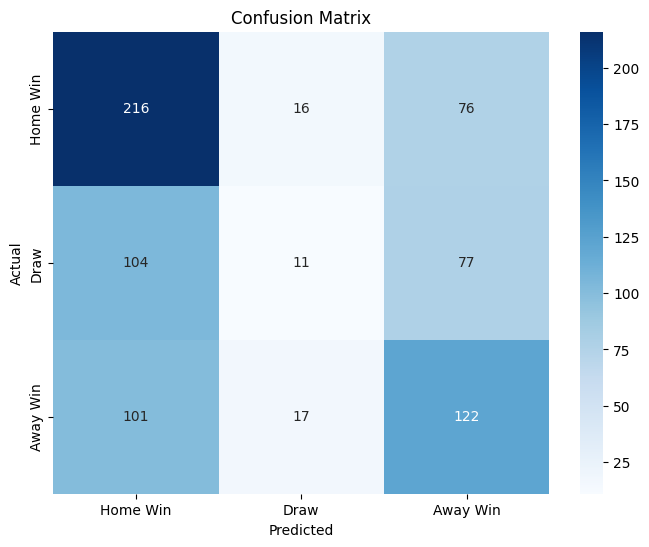

In [343]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Home Win', 'Draw', 'Away Win'], yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()  